In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

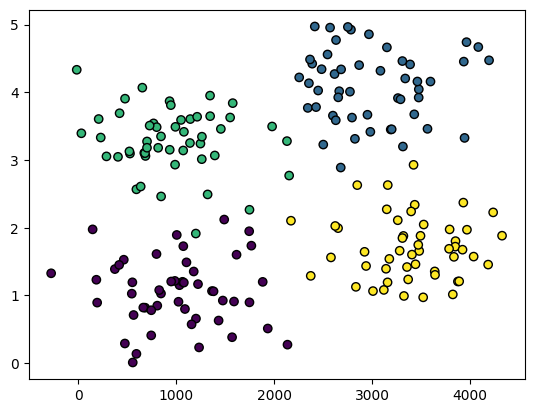

In [3]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [6]:
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)

In [7]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [8]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [9]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [13]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

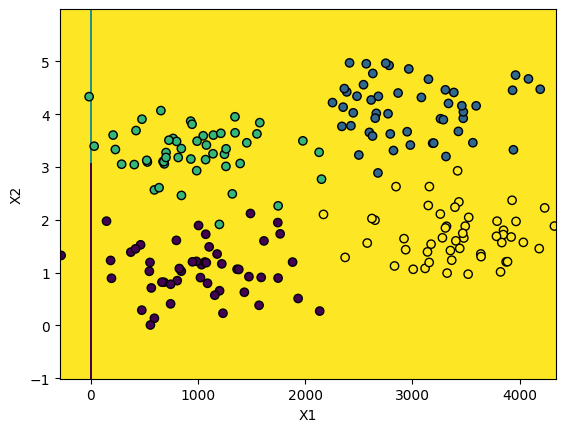

In [11]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

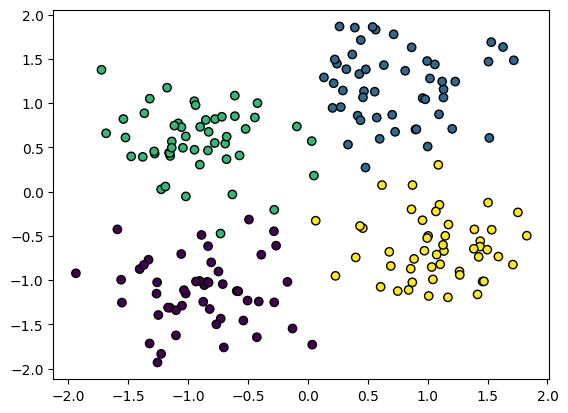

In [22]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.show()

In [23]:
confusion_matrix(y, clf.predict(X_scaled))

array([[ 0,  9,  0, 41],
       [ 0, 50,  0,  0],
       [ 0, 22, 28,  0],
       [ 0, 50,  0,  0]])

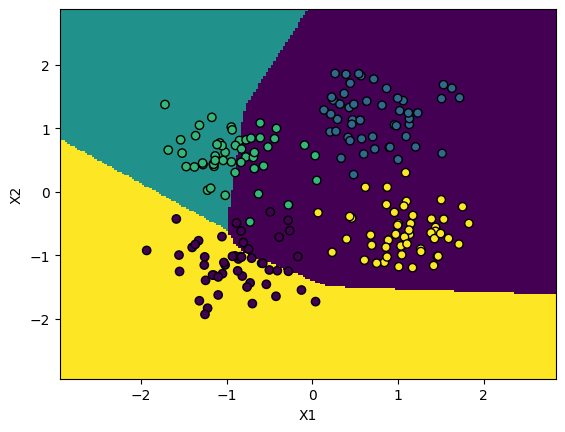

In [24]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [26]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.72431068
Iteration 2, loss = 1.71827143
Iteration 3, loss = 1.71226546
Iteration 4, loss = 1.70629801
Iteration 5, loss = 1.70037857
Iteration 6, loss = 1.69449401
Iteration 7, loss = 1.68864846
Iteration 8, loss = 1.68284746
Iteration 9, loss = 1.67707643
Iteration 10, loss = 1.67133312
Iteration 11, loss = 1.66561474
Iteration 12, loss = 1.65992185
Iteration 13, loss = 1.65426040
Iteration 14, loss = 1.64864444
Iteration 15, loss = 1.64306476
Iteration 16, loss = 1.63751311
Iteration 17, loss = 1.63199645
Iteration 18, loss = 1.62650854
Iteration 19, loss = 1.62104875
Iteration 20, loss = 1.61561732
Iteration 21, loss = 1.61021449
Iteration 22, loss = 1.60484009
Iteration 23, loss = 1.59949999
Iteration 24, loss = 1.59419673
Iteration 25, loss = 1.58892407
Iteration 26, loss = 1.58368014
Iteration 27, loss = 1.57846611
Iteration 28, loss = 1.57328434
Iteration 29, loss = 1.56813337
Iteration 30, loss = 1.56301089
Iteration 31, loss = 1.55791553
Iteration 32, los

In [27]:
confusion_matrix(y, clf.predict(X_scaled))

array([[49,  0,  1,  0],
       [ 0, 50,  0,  0],
       [ 2,  0, 48,  0],
       [ 0,  1,  0, 49]])

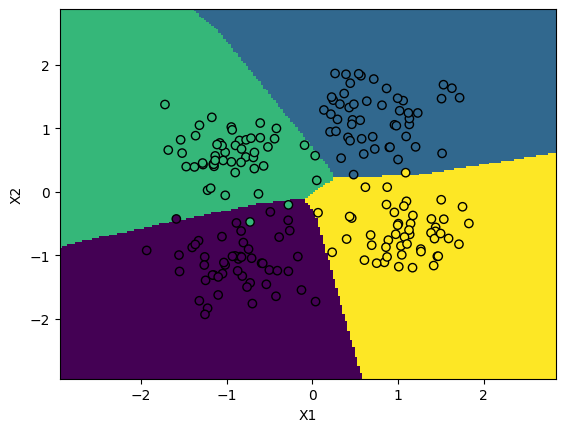

In [28]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [29]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X_scaled, y)

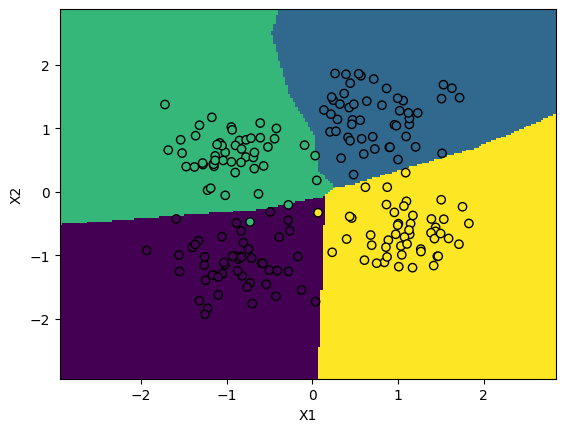

In [30]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Практическая работа

### 1. Однослойный перцептрон с 1, 2, 10, 100 нейронами

In [39]:
for neuro in [1, 2, 10, 100]:
    clf = MLPClassifier(hidden_layer_sizes=(neuro,), max_iter=10000, random_state=1).fit(X_scaled, y)
    print(f"\nДля перцептрона с {neuro} нейронами score = {clf.score(X_scaled, y)}")
    print(confusion_matrix(y, clf.predict(X_scaled)))


Для перцептрона с 1 нейронами score = 0.25
[[ 0  0 50  0]
 [ 0  0 50  0]
 [ 0  0 50  0]
 [ 0  0 50  0]]

Для перцептрона с 2 нейронами score = 0.98
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  2 47  0]
 [ 0  1  0 49]]

Для перцептрона с 10 нейронами score = 0.98
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  1 48  0]
 [ 0  1  0 49]]

Для перцептрона с 100 нейронами score = 0.995
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


**Достаточно 2 нейронов**: 
- 1 нейрон → 25% (плохо)
- 2 нейрона → 98% (отлично)
- 10-100 нейронов → улучшение незначительное (≤1.5%)

### 2. Разное количество слоев

In [40]:
neuro = 4

In [42]:
for hidden_layer_num in [2, 3, 10]:
    clf = MLPClassifier(hidden_layer_sizes=(neuro,) * hidden_layer_num, max_iter=10000, random_state=1).fit(X_scaled, y)
    print(f"\nДля перцептрона с {hidden_layer_num} скрытыми слоями = {clf.score(X_scaled, y)}")
    print(confusion_matrix(y, clf.predict(X_scaled)))


Для перцептрона с 2 скрытыми слоями = 0.98
[[49  0  1  0]
 [ 0 50  0  0]
 [ 2  0 48  0]
 [ 1  0  0 49]]

Для перцептрона с 3 скрытыми слоями = 0.975
[[49  0  1  0]
 [ 0 50  0  0]
 [ 2  0 48  0]
 [ 1  1  0 48]]

Для перцептрона с 10 скрытыми слоями = 0.53
[[ 2 45  0  3]
 [ 0 50  0  0]
 [ 1  0 45  4]
 [ 0  0 41  9]]


**Достаточно 2 слоев**, так как:

- **2 слоя**: 98% точности (оптимально)
- **3 слоя**: 97.5% (незначительное ухудшение)
- **10 слоев**: 53% (переобучение)

### 3. Веса всех нейронов на всех слоях

In [44]:
clf_10 = MLPClassifier(hidden_layer_sizes=(neuro,) * 10, max_iter=10000, random_state=1).fit(X_scaled, y)

for i in range(len(clf_10.coefs_)):
    number_neurons_in_layer = clf_10.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf_10.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.79403043 -1.51160715], 
0 1 [ 0.38822245 -1.52752896], 
0 2 [-0.90731365 -1.63091707], 
0 3 [-1.24168332 -0.45336538], 

1 0 [0.3929767  0.17082722 1.35819372 0.47719648], 
1 1 [1.49045989 0.93590007 1.52319186 1.47857109], 
1 2 [-3.51403876e-02 -6.42159300e-03 -6.96723250e-06 -1.66896497e-02], 
1 3 [ 1.84138004e-06 -1.59635776e-03  1.06364494e-05 -3.07117684e-02], 

2 0 [ 1.634559    1.30388994  0.0419123  -0.01257968], 
2 1 [ 8.72642666e-01  4.32422188e-01  2.38311195e-04 -7.12622038e-20], 
2 2 [ 1.03022542e-05 -3.88456876e-02 -5.89003762e-05  1.51640700e-02], 
2 3 [ 2.24015490e-01  6.77310832e-01  1.08991866e-03 -2.72013177e-05], 

3 0 [-1.98974403e+00  1.58290697e-03 -1.27634514e-02 -1.19991463e+00], 
3 1 [-2.03368976e+00 -5.42114875e-01 -1.52351274e-12  1.66541230e-01], 
3 2 [2.95357673e-01 6.23206425e-01 1.23208620e-05 1.42656308e-01], 
3 3 [-2.57700539e-02  1.77567812e-05 -1.46744730e-12  9.49479736e-32], 

4 0 [-6.39294545e-01  7.15073454e-01  7.03707331e-01 -1.02509052

### 4. Большое количество нейронов и слоев

In [45]:
import time

In [46]:
models = [
    ("1 слой, 2 нейрона", (2,)),
    ("2 слоя, 10 нейронов", (10, 10)),
    ("5 слоев, 20 нейронов", (20,) * 5),
    ("10 слоев, 50 нейронов", (50,) * 10),
]

In [47]:
times = []
names = []
scores = []

In [49]:
for name, layers in models:
    start = time.time()
    clf = MLPClassifier(hidden_layer_sizes=layers, max_iter=10000, random_state=1)
    clf.fit(X_scaled, y)
    elapsed = time.time() - start
    
    accuracy = clf.score(X_scaled, y)
    
    print(f"{name} | время = {elapsed:.3f} | точность = {accuracy:.3f}")
    
    times.append(elapsed)
    names.append(name)
    scores.append(accuracy)

1 слой, 2 нейрона | время = 0.248 | точность = 0.980
2 слоя, 10 нейронов | время = 0.100 | точность = 0.990
5 слоев, 20 нейронов | время = 0.067 | точность = 0.990
10 слоев, 50 нейронов | время = 0.135 | точность = 1.000


**Время обучения:**
- 5 слоев (20 нейронов) — **самое быстрое** (0.067 сек)
- 10 слоев (50 нейронов) — 0.135 сек (в 2 раза медленнее)
- 1-2 слоя — среднее время (0.1-0.25 сек)

**Точность:**
- Все модели показывают **отличный результат** (0.98-1.00)
- 10 слоев достигли **идеальной точности** (1.00)

### 5. Строим и оцениваем модель классификации с перцептроном

In [50]:
from sklearn.datasets import load_wine

In [51]:
wine = load_wine()
X, y = wine.data, wine.target

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
mlp_simple = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
start_simple = time.time()
mlp_simple.fit(X_scaled, y)
simple_time = time.time() - start_simple
simple_acc = accuracy_score(y, mlp_simple.predict(X_scaled))

In [59]:
print(f"Время обучения: {simple_time:.4f} сек")
print(f"Точность на обучающих данных: {simple_acc:.4f}\n")

Время обучения: 0.0957 сек
Точность на обучающих данных: 1.0000



Простая архитектура (1 слой, 5 нейронов) оптимальна

### 6. Модель регрессии

In [68]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

In [61]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

In [63]:
X_scaled = StandardScaler().fit_transform(X)
y_scaled = StandardScaler().fit_transform(y.reshape(-1, 1)).ravel()

In [66]:
mlp_simple = MLPRegressor(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
start_simple = time.time()
mlp_simple.fit(X_scaled, y_scaled)
simple_time = time.time() - start_simple

In [72]:
print(f"Score = {mlp_simple.score(X_scaled, y_scaled)}, time = {simple_time}")

Score = 0.7323677822557092, time = 0.9257469177246094
